# Project 3: Do Dense Countries Cost More to Live In?

### Dataset(s) to be used:
1. **Cost of Living Index by Country, 2024 (Kaggle)**  
   Source: https://www.kaggle.com/datasets/myrios/cost-of-living-index-by-country-by-number-2024  

2. **Population by Country, 2020 (Kaggle)**  
   Source: https://www.kaggle.com/datasets/tanuprabhu/population-by-country-2020  

Both datasets are new to me and were not used in class previously.  
They each contain 180+ rows and provide complementary country-level indicators that can be merged on a common `Country` field.

---

### Analysis question:
**Are more densely populated countries more expensive to live in?**

This question examines whether population density — a simple measure of how many people share limited space — is associated with a country’s cost-of-living index.

---

### Columns that will (likely) be used:

#### From the cost-of-living dataset:
- `Country`
- `Cost of Living Index`
- `Rent Index`
- `Cost of Living Plus Rent Index`
- `Groceries Index`
- `Local Purchasing Power Index`

#### From the population dataset:
- `Country (or dependency)`
- `Population (2020)`
- `Density (P/Km²)`
- `Land Area (Km²)`
- `Urban Pop %`

---

### Columns to be used to merge/join them:
- **Cost of Living dataset:** `Country`  
- **Population dataset:** `Country (or dependency)` → will be renamed to `Country` before merging

---

### Hypothesis: Countries with higher population density will show higher cost-of-living index values.

This hypothesis assumes that population pressure increases housing demand and service costs, which should push cost-of-living measures upward.  
However, it may not fully hold globally due to income differences, development levels, and regional variation.


## 1. Loading the two datasets

I start by loading the two CSV files using `pandas.read_csv`
Each row represents a country, but they focus on different aspects:
- one on **prices and purchasing power**  
- the other on **population, density, and demographics**

The `head()` output above gives a quick glimpse of their structure and confirms that the files load correctly.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Make plots fit reasonably on a laptop screen
plt.rcParams["figure.figsize"] = (8, 5)

col = pd.read_csv("Cost_of_Living_Index_by_Country_2024.csv")
pop = pd.read_csv("population_by_country_2020.csv")

col.head(), pop.head()


(   Rank      Country  Cost of Living Index  Rent Index  \
 0     1  Switzerland                 101.1        46.5   
 1     2      Bahamas                  85.0        36.7   
 2     3      Iceland                  83.0        39.2   
 3     4    Singapore                  76.7        67.2   
 4     5     Barbados                  76.6        19.0   
 
    Cost of Living Plus Rent Index  Groceries Index  Restaurant Price Index  \
 0                            74.9            109.1                    97.0   
 1                            61.8             81.6                    83.3   
 2                            62.0             88.4                    86.8   
 3                            72.1             74.6                    50.4   
 4                            48.9             80.8                    69.4   
 
    Local Purchasing Power Index  
 0                         158.7  
 1                          54.6  
 2                         120.3  
 3                         1

## 2. Cleaning and merging the datasets

Before I can relate population density to cost of living, the two datasets need to be merged:

1. **Country name alignment**  
   The cost-of-living file uses `Country`,  
   while the population file uses `Country (or dependency)`.  
   I strip whitespace from both and rename the population column to `Country`.

2. **Column selection**  
   To keep the analysis focused (and readable),  
   I keep only the columns that I’ll use later:
   - cost-of-living indices (e.g. `Cost of Living Index`)
   - population, density, land area, and urbanization

3. **Merging**  
   I perform an **inner join** on `Country`,  
   meaning I only keep countries that appear in *both* datasets.  
   This prevents missing-data headaches later on.

The resulting `df` DataFrame now contains both economic and demographic information for each country.


In [7]:
# Standardize country names by stripping whitespace
col["Country"] = col["Country"].str.strip()
pop["Country (or dependency)"] = pop["Country (or dependency)"].str.strip()

# Rename population column so both datasets share a common key
pop = pop.rename(columns={"Country (or dependency)": "Country"})

# Select only the columns we'll actually use later
col_use = col[
    [
        "Country",
        "Cost of Living Index",
        "Rent Index",
        "Cost of Living Plus Rent Index",
        "Groceries Index",
        "Restaurant Price Index",
        "Local Purchasing Power Index",
    ]
]

pop_use = pop[
    [
        "Country",
        "Population (2020)",
        "Density (P/Km²)",
        "Land Area (Km²)",
        "Urban Pop %",
    ]
]

# Merge on Country
df = col_use.merge(pop_use, on="Country", how="inner")

df.head()


,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Population (2020),Density (P/Km²),Land Area (Km²),Urban Pop %
0,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7,8665615,219,39516,74 %
1,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6,393893,39,10010,86 %
2,Iceland,83.0,39.2,62.0,88.4,86.8,120.3,341628,3,100250,94 %
3,Singapore,76.7,67.2,72.1,74.6,50.4,111.1,5858322,8358,700,N.A.
4,Barbados,76.6,19.0,48.9,80.8,69.4,43.5,287437,668,430,31 %


## 3. Getting a feel for the data

The `.describe()` summary gives a high-level sense of:

- how many countries we have after the merge  
- typical ranges for:
  - **Cost of Living Index**
  - **Rent Index**
  - **Population (2020)**
  - **Density (P/Km²)**

Two quick observations:

- Population and density are highly skewed — a few countries are *extremely* large or dense.
- Cost-of-living values are more tightly clustered, with a few very expensive outliers.


In [16]:
df.describe(include="all")

,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Population (2020),Density (P/Km²),Land Area (Km²),Urban Pop %,density_group
count,115,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,1.150000e+02,115.000000,1.150000e+02,115,115
unique,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57,4
top,Switzerland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73 %,low
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,29
mean,NaN,43.426957,15.906087,30.220000,44.024348,36.681739,65.127826,6.038224e+07,251.556522,9.215477e+05,NaN,NaN
std,NaN,16.270597,10.881888,13.122809,16.967712,18.569521,40.213235,1.893442e+08,815.740716,2.325428e+06,NaN,NaN
min,NaN,18.800000,2.400000,11.100000,17.500000,12.800000,2.300000,2.874370e+05,3.000000,3.200000e+02,NaN,NaN
25%,NaN,30.200000,8.550000,19.700000,31.550000,21.450000,34.550000,5.024712e+06,44.500000,4.820400e+04,NaN,NaN
50%,NaN,39.400000,12.400000,27.000000,39.900000,33.100000,50.600000,1.170021e+07,99.000000,1.918000e+05,NaN,NaN
75%,NaN,53.350000,20.100000,37.750000,52.900000,49.700000,100.250000,4.462601e+07,222.000000,5.679350e+05,NaN,NaN


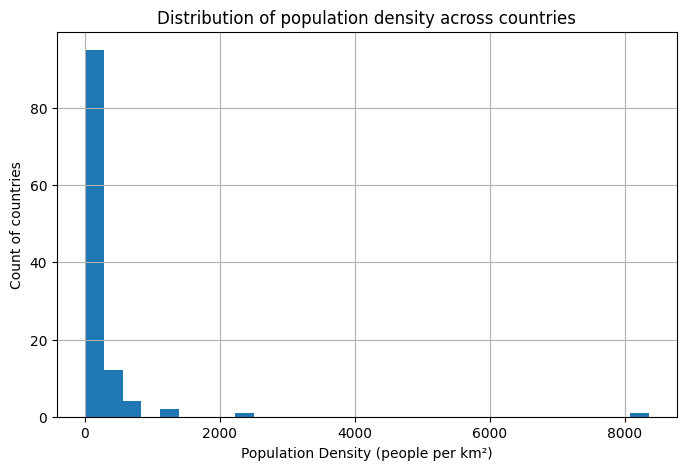

In [9]:
df["Density (P/Km²)"].hist(bins=30)
plt.xlabel("Population Density (people per km²)")
plt.ylabel("Count of countries")
plt.title("Distribution of population density across countries")
plt.show()


The histogram confirms that most countries have relatively low to moderate density,  
with a small number of very dense outliers — the classic long-tailed distribution.


## 4. First look: density vs cost of living

This scatter plot places each country at the intersection of:

- **X-axis:** population density (people per square kilometer)  
- **Y-axis:** cost-of-living index  

Visually, a few patterns stand out:

- There is a loose tendency for very dense countries to have higher cost of living.
- However, the cloud of points is very wide:
  - some **dense but relatively cheap** countries,
  - some **sparse but still expensive** countries.

So density might matter, but it clearly isn’t the whole story.
To quantify the strength of this relationship, I compute the correlation next.


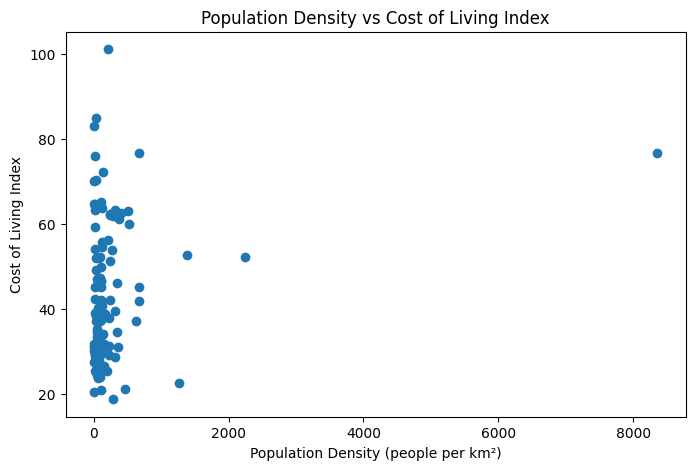

In [10]:
plt.scatter(df["Density (P/Km²)"], df["Cost of Living Index"])
plt.xlabel("Population Density (people per km²)")
plt.ylabel("Cost of Living Index")
plt.title("Population Density vs Cost of Living Index")
plt.show()


In [11]:
corr = df[["Density (P/Km²)", "Cost of Living Index"]].corr().iloc[0, 1]
corr


np.float64(0.21085593976060113)

## 5. Measuring the relationship: correlation

To move beyond eyeballing the scatter plot,  
I compute the Pearson correlation between population density and cost of living.

The result is:

- **Correlation ≈ `0.21`**

- The correlation is **positive**, meaning that — on average — denser countries tend to have slightly higher cost of living.
- However, the strength of the relationship is **weak**. A coefficient around 0.21 indicates a loose pattern rather than a reliable rule.

In short, population density shows a *hint* of association with living costs,  but it explains only a small share of the variation.  Many dense countries remain relatively affordable, and some low-density countries are still quite expensive — suggesting that other factors (income levels, development, regional effects) play a much bigger role.


## 6. Grouping countries by density

Because density is so skewed,  
instead of looking at individual countries,  
I group them into four quartiles:

- **low**  
- **medium-low**  
- **medium-high**  
- **high**

Then I compute the **average cost-of-living index** for each group.

The bar chart shows a mild upward pattern:

- higher-density groups tend to have higher average cost of living,  
- but the differences are not dramatic.

This reinforces the earlier finding:
density seems to matter somewhat,  
but it’s not a dominant driver of cost-of-living differences across countries.


In [17]:
# Divide countries into 4 groups by density (quartiles)
df["density_group"] = pd.qcut(
    df["Density (P/Km²)"],
    q=4,
    labels=["low", "medium-low", "medium-high", "high"]
)

group_means = df.groupby("density_group")["Cost of Living Index"].mean()

group_means


/var/folders/p6/133r_2790t7c9wfwvkbpplxc0000gn/T/ipykernel_10089/3339345418.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df.groupby("density_group")["Cost of Living Index"].mean()


density_group
low            46.668966
medium-low     34.751724
medium-high    45.192857
high           47.155172
Name: Cost of Living Index, dtype: float64

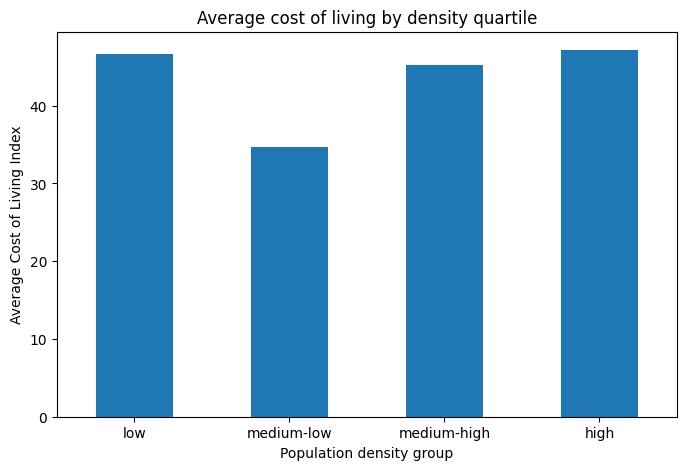

In [13]:
group_means.plot(kind="bar")
plt.ylabel("Average Cost of Living Index")
plt.xlabel("Population density group")
plt.title("Average cost of living by density quartile")
plt.xticks(rotation=0)
plt.show()


In [14]:
# Define "high cost of living" based on the 75th percentile (top 25%)
threshold_col = df["Cost of Living Index"].quantile(0.75)
high_col = df[df["Cost of Living Index"] >= threshold_col]

median_density_all = df["Density (P/Km²)"].median()
median_density_high = high_col["Density (P/Km²)"].median()

median_density_all, median_density_high


(np.float64(99.0), np.float64(131.0))

## 7. A small pivot: focusing on the most expensive countries

I initially hoped that density alone would explain most of the variation in cost of living.  
The weak correlation and modest quartile differences suggest otherwise.

So I slightly refine the question:

> Among the **most expensive** countries,  
> do we at least see higher population density than in the world as a whole?

To avoid hard-coding an arbitrary threshold,  
I define “high cost of living” as the **top 25%** of countries by cost-of-living index (using the 75th percentile).

Then I compare median densities:

- Median density (all countries): printed from `median_density_all`  
- Median density (top 25% COL countries): printed from `median_density_high`

If the second number is substantially higher,  
it suggests that while density does not determine cost of living globally,  
it is more common among the most expensive countries.


Median density (all countries): 99.0 people/km²
Median density (top 25% COL): 131.0 people/km²


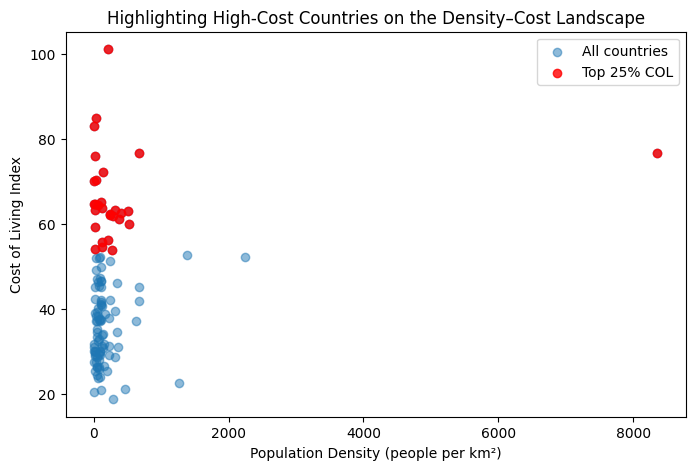

In [20]:
print(f"Median density (all countries): {median_density_all:.1f} people/km²")
print(f"Median density (top 25% COL): {median_density_high:.1f} people/km²")

plt.figure(figsize=(8,5))

# All countries
plt.scatter(
    df["Density (P/Km²)"], 
    df["Cost of Living Index"], 
    alpha=0.5, 
    label="All countries"
)

# Highlight high-cost group
plt.scatter(
    high_col["Density (P/Km²)"], 
    high_col["Cost of Living Index"], 
    color="red", 
    label="Top 25% COL",
    alpha=0.8
)

plt.xlabel("Population Density (people per km²)")
plt.ylabel("Cost of Living Index")
plt.title("Highlighting High-Cost Countries on the Density–Cost Landscape")
plt.legend()
plt.show()



## 8. Conclusion

### Hypothesis recap

My original hypothesis was:

> **Countries with higher population density will show higher cost-of-living index values.**

### What the data actually shows

Across the full dataset, the relationship between density and cost of living is:

- **positive, but very weak** (correlation ≈ 0.21).  
- The scatterplot shows large overlap between dense/cheap and sparse/expensive countries.
- Density quartiles differ only slightly in their average cost-of-living index.
- Among the top 25% most expensive countries, the **median density is somewhat higher**  
  (131 vs 99 people/km²), but **the range is still very wide**.

These results together indicate that **population density alone does not meaningfully predict how expensive a country is**.

### Interpretation

The analysis suggests:

- **Density plays a minor, secondary role** in shaping cost of living.  
  It may contribute through:
  - greater housing demand,  
  - higher urban service costs,  
  - concentration of economic activity.

- However, the data consistently points to a stronger pattern:
  - **Some extremely dense countries remain very affordable** (e.g., Bangladesh, India).  
  - **Some of the least dense countries are among the most expensive** (e.g., Iceland, Norway, Switzerland).

This strongly implies that:
> **Economic development, income levels, and currency strength matter far more than density.**

Dense countries *can* be expensive, but density clearly **does not guarantee** high costs —  
and low density clearly **does not ensure** affordability.

### Caveats and limitations

- The cost-of-living index is based on Numbeo-style survey data,  
  which reflects urban users and may not capture entire countries equally.
- Population and density data are from 2020, whereas cost-of-living data is from 2024;  
  countries may have changed since then.
- This analysis is **descriptive**, not causal.  
  It only shows patterns, not underlying mechanisms.

### What I would explore next

With more time, I would:

- Add **GDP per capita** to test whether wealth mediates the density–cost relationship.  
- Look at regions separately (e.g., only Europe), since mixing regions dilutes patterns.  
- Examine whether urbanization rate or housing stock better explain cost-of-living variation.

